#  Simulation for PW#14

### Setup notebook

In [1]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

### Imports

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PlatoSim
import platosim.plot            as pt
import platosim.utilities       as ut
import platosim.referenceFrames as rf
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

## Load all simulations

In [3]:
# Load light curve object for the first star only and unpack the data
idir = os.getenv("PLATO_WORKDIR") + "/pw14/input"
odir = os.getenv("PLATO_WORKDIR") + "/pw14/output"

In [4]:
# Fetch all variable source files
lcs = LightCurve(idir, mode="multi")
vfiles = lcs.files("txt", "varsource")
vfiles

['/lhome/nicholas/software/workdir//pw14/input/varsource_algol.txt',
 '/lhome/nicholas/software/workdir//pw14/input/varsource_gDor.txt',
 '/lhome/nicholas/software/workdir//pw14/input/varsource_std.txt']

## 1 - Gamma Doradus star

In [10]:
# Load input model
df = pd.read_csv('/lhome/nicholas/software/workdir/pw14/input/GammaDor_ForNich.txt', sep='    ', names=['time', 'dmag'])
df.time *= 86400.

/tmp/ipykernel_1684201/2898577102.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('/lhome/nicholas/software/workdir/pw14/input/GammaDor_ForNich.txt', sep='    ', names=['time', 'dmag'])


In [11]:
# Save PlatoSim compatible varsource file
df.to_csv(idir + '/varsource_gDor.txt', sep=' ', index=False, float_format='%.5f')

<IPython.core.display.Javascript object>


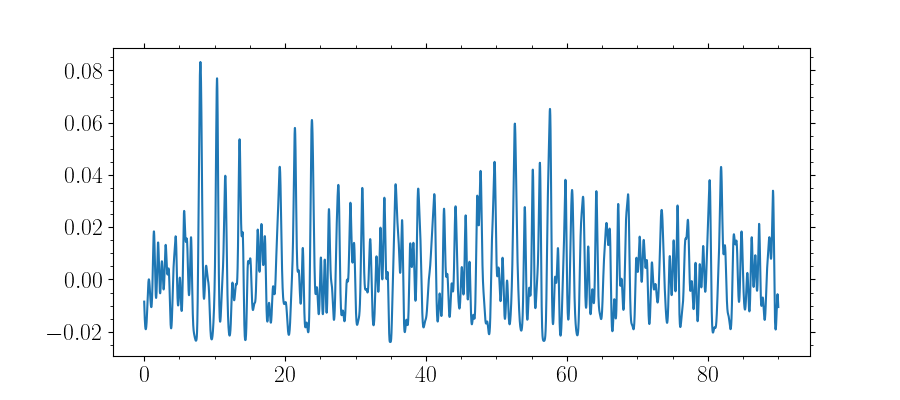

In [12]:
# Plot the input files
plt.figure(figsize=(9,4))
plt.plot(df.time/86400, df.dmag);

In [26]:
# Fetch all simulations
lcs = LightCurve(odir, mode="multi")
filenames = lcs.files("hdf5", "sim1")
lc11 = LightCurve(filenames[0])
lc12 = LightCurve(filenames[1])
lc13 = LightCurve(filenames[2])


<IPython.core.display.Javascript object>


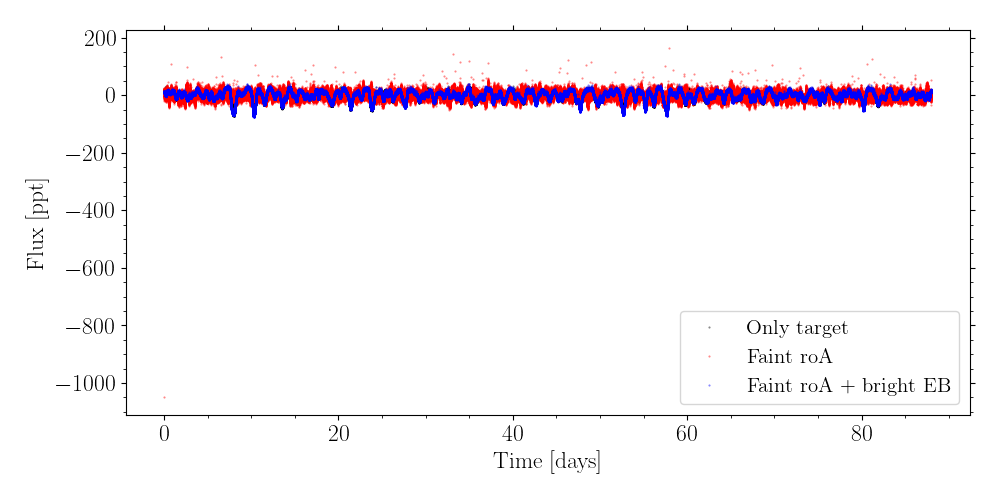

In [27]:
# Plot comparison figure
plt.figure(figsize=(10,5))
plt.plot(lc11.time(unit='d'), lc11.flux(unit='ppt'), 'k.', ms=1, alpha=0.5, label='Only target')
plt.plot(lc12.time(unit='d'), lc12.flux(unit='ppt'), 'r.', ms=1, alpha=0.5, label='Faint roA')
plt.plot(lc13.time(unit='d'), lc13.flux(unit='ppt'), 'b.', ms=1, alpha=0.5, label='Faint roA + bright EB')
plt.xlabel('Time [days]')
plt.ylabel('Flux [ppt]')
plt.legend()
plt.tight_layout();

In [ ]:
# Time series of 2 years using the latter setup
lcs = LightCurve(odir, mode="multi")
filenames = lcs.files("hdf5", "sim14")
lc11 = LightCurve(filenames[0])

## 2 - Delta Scuti star

In [ ]:
df = 

## 3 - EB of Algol type

<IPython.core.display.Javascript object>


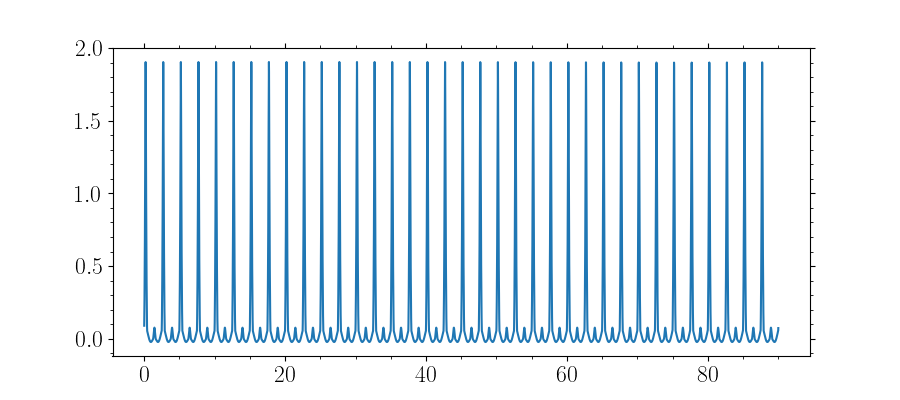

In [5]:
# Show input variability
dv = LightCurve(vfiles[0]).data()
plt.figure(figsize=(9,4))
plt.plot(dv.time/86400, dv.dmag);

In [6]:
# Fetch all simulations
lcs = LightCurve(odir, mode="multi")
filenames = lcs.files("hdf5", "sim3")
lc31 = LightCurve(filenames[0])
lc32 = LightCurve(filenames[1])
lc33 = LightCurve(filenames[2])

<IPython.core.display.Javascript object>


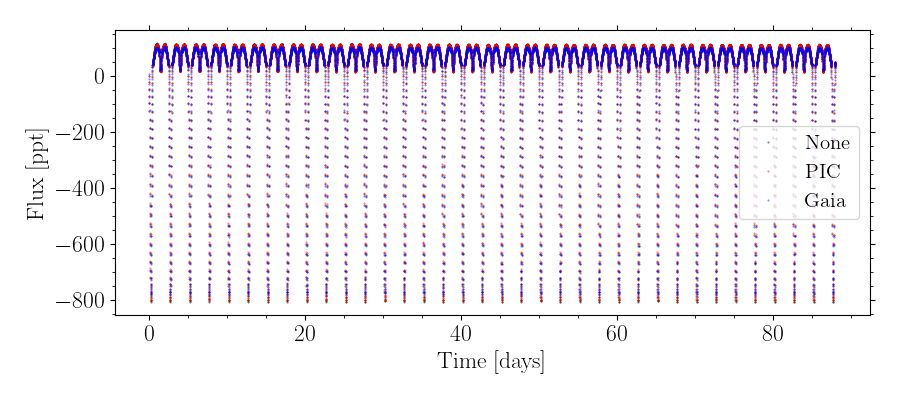

In [7]:
# Plot comparison figure
plt.figure(figsize=(9,4))
plt.plot(lc31.time(unit='d'), lc31.flux(unit='ppt'), 'k.', ms=1, alpha=0.5, label='None')
plt.plot(lc32.time(unit='d'), lc32.flux(unit='ppt'), 'r.', ms=1, alpha=0.5, label='PIC')
plt.plot(lc33.time(unit='d'), lc33.flux(unit='ppt'), 'b.', ms=1, alpha=0.5, label='Gaia')
plt.xlabel('Time [days]')
plt.ylabel('Flux [ppt]')
plt.legend()
plt.tight_layout();

In [8]:
# Save results
df = lc31.data().drop(['flux', 'flux_input'], axis=1)
df['flux31'] = lc31.data()['flux']
df['flux32'] = lc32.data()['flux']
df['flux33'] = lc33.data()['flux']
df.to_feather('sim3results.ftr')

In [10]:
# Merge all N-CAM light curves
# lc, ncam, flag = lcs.merge(quarter=1, flux_group_mean=True, suffix='hdf5')
# lc.data()